### Schaue ein Bild mit Bounding box an

In [7]:
import zipfile

with zipfile.ZipFile('Data/MZ Projekt V1.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/MZ Projekt V1')

In [8]:
with zipfile.ZipFile('Data/MZ Projekt V1/Negativ 12241515.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/Negativ 12241515')

with zipfile.ZipFile('Data/MZ Projekt V1/Pos_neg 12241515.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/Pos_neg 12241515')

In [9]:
import os
from collections import Counter

# Pfad zu deinem Ordner mit den Label-Dateien
label_folder = r'C:\Users\Flo\Desktop\Studium\6. Semester\BA\Data\Pos_neg 12241515\labels\Train'  # Passe diesen Pfad an

def count_yolo_classes(folder_path):
    class_counts = Counter()
    file_count = 0

    if not os.path.exists(folder_path):
        print(f"Fehler: Der Ordner {folder_path} wurde nicht gefunden.")
        return

    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            file_count += 1
            with open(os.path.join(folder_path, filename), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        # Die erste Zahl in der Zeile ist die Klassen-ID
                        class_id = parts[0]
                        class_counts[class_id] += 1

    print(f"--- Analyse abgeschlossen ---")
    print(f"Anzahl bearbeiteter Dateien: {file_count}")
    print("Verteilung der Klassen (ID: Anzahl Bounding Boxes):")
    for cid, count in sorted(class_counts.items()):
        # Hier kannst du die Namen manuell ergänzen, z.B. 0: 'Atypisch', 1: 'Normal'
        label_name = "Atypisch" if cid == '0' else "Normal"
        print(f"  Klasse {cid} ({label_name}): {count}")

In [10]:
count_yolo_classes(label_folder)

Fehler: Der Ordner C:\Users\Flo\Desktop\Studium\6. Semester\BA\Data\Pos_neg 12241515\labels\Train wurde nicht gefunden.


In [2]:
import cv2
import os
import matplotlib.pyplot as plt

# Pfade anpassen
image_path = r'D:\Studium\6. Semester\BA\hpc\Data\Pos_neg 12241515\images\Train\tile_12_38.jpg'
label_path = r'D:\Studium\6. Semester\BA\hpc\Data\Pos_neg 12241515\labels\Train\tile_12_38.txt'

def show_boxes_stable(img_path, lbl_path):
    if not os.path.exists(img_path):
        print(f"Fehler: Bild nicht gefunden unter {img_path}")
        return

    # Bild laden
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV lädt BGR, Matplotlib braucht RGB
    h, w, _ = img.shape

    # Labels einlesen, falls vorhanden
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) == 5:
                    class_id, x_c, y_c, bw, bh = map(float, parts)
                    
                    # Umrechnen von normierten YOLO-Werten in Pixel
                    x1 = int((x_c - bw / 2) * w)
                    y1 = int((y_c - bh / 2) * h)
                    x2 = int((x_c + bw / 2) * w)
                    y2 = int((y_c + bh / 2) * h)

                    # Zeichnen
                    color = (0, 255, 0) if int(class_id) == 0 else (255, 0, 0)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                    plt.text(x1, y1-5, f"ID: {int(class_id)}", color='white', 
                             fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    # Bild ausgeben
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_boxes_stable(image_path, label_path)


Fehler: Bild nicht gefunden unter D:\Studium\6. Semester\BA\hpc\Data\Pos_neg 12241515\images\Train\tile_12_38.jpg


### Versuche erste Schritte wo ganz dunkle stellen ausgeschwärzt werden.

In [12]:
try:
    import cv2 as cv
    import numpy
    import matplotlib.pyplot as plt
except:
    !pip install opencv-python
    !pip install numpy
    !pip install matplotlib

In [13]:

import matplotlib.pyplot as plt

os.getcwd()

negatives = "Data/Negativ 12241515/images/train"
positives = "Data/Pos_neg 12241515/images/Train"

img_path = os.path.join(negatives, "tile_134_37.jpg")
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

mask = gray < 15

img[mask] = 0


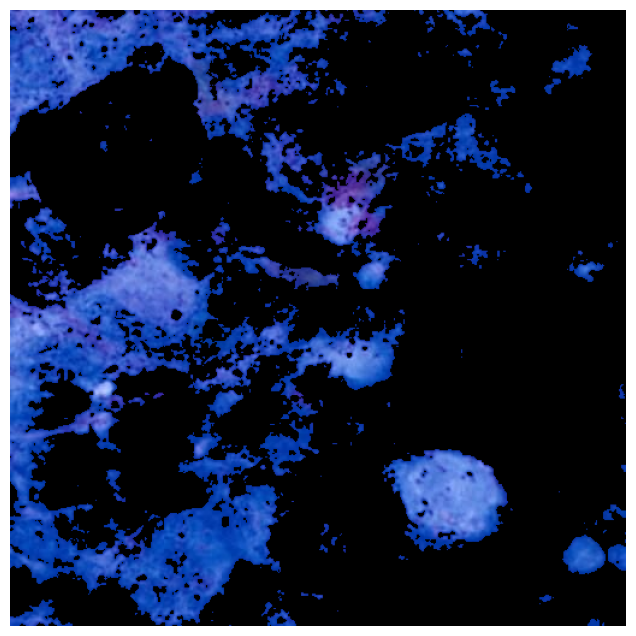

In [14]:

img_bgr = cv.imread(img_path)
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
img_bgr[img_gray < 50] = [0, 0, 0]


img_display = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_display)
plt.axis('off')
plt.show()

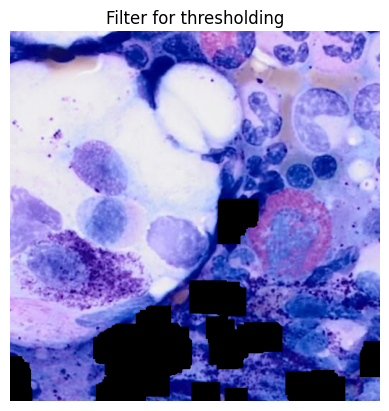

In [15]:
import numpy as np

img_path = os.path.join(negatives, "tile_149_15.jpg")
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img = cv.imread(img_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Initiale Maske für dunkle Bereiche
mask = (gray < 100).astype(np.uint8) * 255 

# 2. Morphologische Reinigung (Opening)
# Ein Kernel von 5x5 oder 7x7 bestimmt, wie "gross" die Fläche sein muss.
# Je grösser der Kernel, desto grösser muss die dunkle Fläche sein, um geschwärzt zu werden.
kernel = np.ones((30, 30), np.uint8)
cleaned_mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)

# 3. Maske anwenden
# Wir schwärzen das Bild nur dort, wo die GEREINIGTE Maske aktiv ist
img_rgb[cleaned_mask == 255] = [0, 0, 0]

# Anzeige
plt.imshow(img_rgb)
plt.title("Filter for thresholding")
plt.axis('off')
plt.show()

In [44]:
os.listdir()
# os.chdir(path="Pos_neg 12241515")
# os.getcwd()

['data.yaml', 'images', 'labels', 'Train.txt']

In [68]:
import os
import glob
import cv2 as cv
import numpy as np
import albumentations as A

# 1. Konfiguration
# Nutze absolute Pfade, um Fehler zu vermeiden
BASE_DIR = os.getcwd()
INPUT_IMG_DIR = os.path.join(BASE_DIR, "images", "Train")
OUTPUT_TEST_DIR = os.path.join(BASE_DIR, "augmentation_check")
os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

# 2. Augmentation Pipeline
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(rotate_limit=20, p=0.4, border_mode=cv.BORDER_CONSTANT, value=0),
    A.GaussNoise(p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def draw_yolo_bboxes(img, bboxes, class_labels):
    h, w, _ = img.shape
    for box, cls in zip(bboxes, class_labels):
        x_c, y_c, bw, bh = box
        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)
        
        color = (0, 0, 255) if cls == 0 else (0, 255, 0)
        cv.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv.putText(img, f"Class {cls}", (x1, y1-5), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

# 3. Test-Durchlauf
# Suche explizit nach .jpg Dateien
image_files = glob.glob(os.path.join(INPUT_IMG_DIR, "*.jpg"))

print(f"Suche in: {INPUT_IMG_DIR}")
print(f"Gefundene Bilder: {len(image_files)}")

if len(image_files) == 0:
    print("WARNUNG: Keine Bilder gefunden! Prüfe den Pfad.")

for img_path in image_files[:100]: # Teste die ersten 15 Bilder
    img = cv.imread(img_path)
    if img is None:
        print(f"Fehler beim Laden von: {img_path}")
        continue

    # Pfad-Korrektur für Labels:
    # Wir ersetzen den ORDNER-Namen 'images' durch 'labels' im Gesamtpfad
    lbl_path = img_path.replace(os.sep + "images" + os.sep, os.sep + "labels" + os.sep).replace(".jpg", ".txt")
    
    if not os.path.exists(lbl_path):
        print(f"Skipping: Keine Label-Datei gefunden für {os.path.basename(img_path)}")
        continue

    bboxes = []
    class_labels = []
    
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                class_labels.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:]])
    
    if not bboxes:
        print(f"Skipping: Label-Datei leer für {os.path.basename(img_path)}")
        continue

    # Augmentierung
    try:
        transformed = augmenter(image=img, bboxes=bboxes, class_labels=class_labels)
        img_aug = transformed['image']
        boxes_aug = transformed['bboxes']
        labels_aug = transformed['class_labels']

        # Zeichnen & Speichern
        img_with_boxes = draw_yolo_bboxes(img_aug.copy(), boxes_aug, labels_aug)
        save_path = os.path.join(OUTPUT_TEST_DIR, f"aug_{os.path.basename(img_path)}")
        cv.imwrite(save_path, img_with_boxes)
        print(f"Erfolg: {os.path.basename(save_path)} generiert.")
    except Exception as e:
        print(f"Fehler bei Augmentation von {os.path.basename(img_path)}: {e}")

print(f"\nCheck abgeschlossen! Ergebnisse liegen in: {OUTPUT_TEST_DIR}")

C:\Users\Flo\AppData\Local\Temp\ipykernel_1008\1523940653.py:18: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(rotate_limit=20, p=0.4, border_mode=cv.BORDER_CONSTANT, value=0),


Suche in: d:\Studium\6. Semester\BA\Data\Pos_neg 12241515\images\Train
Gefundene Bilder: 846
Skipping: Keine Label-Datei gefunden für tile_0_15.jpg
Skipping: Keine Label-Datei gefunden für tile_0_16.jpg
Erfolg: aug_tile_0_23.jpg generiert.
Skipping: Keine Label-Datei gefunden für tile_0_24.jpg
Erfolg: aug_tile_0_39.jpg generiert.
Skipping: Keine Label-Datei gefunden für tile_0_51.jpg
Skipping: Keine Label-Datei gefunden für tile_100_13.jpg
Skipping: Keine Label-Datei gefunden für tile_100_14.jpg
Skipping: Keine Label-Datei gefunden für tile_100_31.jpg
Skipping: Keine Label-Datei gefunden für tile_100_45.jpg
Skipping: Keine Label-Datei gefunden für tile_100_46.jpg
Skipping: Keine Label-Datei gefunden für tile_100_82.jpg
Skipping: Keine Label-Datei gefunden für tile_101_15.jpg
Skipping: Keine Label-Datei gefunden für tile_101_16.jpg
Skipping: Keine Label-Datei gefunden für tile_101_27.jpg
Skipping: Keine Label-Datei gefunden für tile_101_50.jpg
Skipping: Keine Label-Datei gefunden für ti

In [70]:
import os
import glob
import cv2 as cv
import numpy as np
import albumentations as A

# 1. Konfiguration
BASE_DIR = os.getcwd()
INPUT_IMG_DIR = os.path.join(BASE_DIR, "images", "Train")
OUTPUT_TEST_DIR = os.path.join(BASE_DIR, "augmentation_check")
os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

# 2. Augmentation Pipeline
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(rotate_limit=20, p=0.4, border_mode=cv.BORDER_CONSTANT, value=0),
    A.GaussNoise(p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def draw_yolo_bboxes(img, bboxes, class_labels, title=None):
    """Zeichnet Boxen und optional einen Titel in das Bild."""
    h, w, _ = img.shape
    img_copy = img.copy()
    for box, cls in zip(bboxes, class_labels):
        x_c, y_c, bw, bh = box
        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)
        
        color = (0, 0, 255) if cls == 0 else (0, 255, 0) # Rot=Atypisch, Grün=Normal
        cv.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
    
    if title:
        cv.putText(img_copy, title, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    return img_copy

# 3. Test-Durchlauf
image_files = glob.glob(os.path.join(INPUT_IMG_DIR, "*.jpg"))
print(f"Gefundene Bilder: {len(image_files)}")

for img_path in image_files[:100]: # Teste 10 Bilder
    img = cv.imread(img_path)
    if img is None: continue

    # Pfad für Labels finden
    lbl_path = img_path.replace(os.sep + "images" + os.sep, os.sep + "labels" + os.sep).replace(".jpg", ".txt")
    
    if not os.path.exists(lbl_path):
        continue

    bboxes = []
    class_labels = []
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                class_labels.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:]])
    
    if not bboxes: continue

    # Augmentierung anwenden
    try:
        transformed = augmenter(image=img, bboxes=bboxes, class_labels=class_labels)
        img_aug = transformed['image']
        boxes_aug = transformed['bboxes']
        labels_aug = transformed['class_labels']

        # Beides zeichnen: Original (links) und Augmentiert (rechts)
        orig_viz = draw_yolo_bboxes(img, bboxes, class_labels, title="Original")
        aug_viz = draw_yolo_bboxes(img_aug, boxes_aug, labels_aug, title="Augmentiert")

        # Bilder horizontal kombinieren
        combined_viz = np.hstack((orig_viz, aug_viz))

        # Speichern
        save_path = os.path.join(OUTPUT_TEST_DIR, f"compare_{os.path.basename(img_path)}")
        cv.imwrite(save_path, combined_viz)
        print(f"Vergleich gespeichert: {os.path.basename(save_path)}")

    except Exception as e:
        print(f"Fehler bei {os.path.basename(img_path)}: {e}")

print(f"\nFertig! Die Vorher-Nachher-Vergleiche liegen in: {OUTPUT_TEST_DIR}")

C:\Users\Flo\AppData\Local\Temp\ipykernel_1008\2531416646.py:17: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(rotate_limit=20, p=0.4, border_mode=cv.BORDER_CONSTANT, value=0),


Gefundene Bilder: 846
Vergleich gespeichert: compare_tile_0_23.jpg
Vergleich gespeichert: compare_tile_0_39.jpg
Vergleich gespeichert: compare_tile_102_29.jpg
Vergleich gespeichert: compare_tile_102_39.jpg
Vergleich gespeichert: compare_tile_102_40.jpg
Vergleich gespeichert: compare_tile_103_16.jpg
Vergleich gespeichert: compare_tile_103_41.jpg
Vergleich gespeichert: compare_tile_104_41.jpg
Vergleich gespeichert: compare_tile_104_65.jpg
Vergleich gespeichert: compare_tile_104_68.jpg
Vergleich gespeichert: compare_tile_105_4.jpg
Vergleich gespeichert: compare_tile_106_9.jpg
Vergleich gespeichert: compare_tile_108_12.jpg
Vergleich gespeichert: compare_tile_108_58.jpg
Vergleich gespeichert: compare_tile_108_6.jpg
Vergleich gespeichert: compare_tile_10_19.jpg
Vergleich gespeichert: compare_tile_10_28.jpg
Vergleich gespeichert: compare_tile_10_58.jpg
Vergleich gespeichert: compare_tile_110_12.jpg
Vergleich gespeichert: compare_tile_111_73.jpg
Vergleich gespeichert: compare_tile_112_41.jpg
V